# Yi-Ning Li
# USC ID: 6454654121
# Github username: yjli27
# DSCI 552
# HW 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# 1. Combined Cycle Power Plant Data Set

## 1(a) Download the Combined Cycle Power Plant data or use provided data from Piazza

## 1(b) Exploring the data

### 1(b)(i) How many rows are in this data set? How many columns? 
###      What do the rows and columns represent?

In [2]:
data=pd.read_excel("../data/CCPP/Folds5x2_pp.xlsx", sheet_name="Sheet1")
data.head()

print("Number of rows: ", data.shape[0])
print("Number of columns: ", data.shape[1])
print("Each row represents an hourly observation from the power plant.")
print("The columns represent hourly average ambient variables Ambient Temperature (AT), Exhaust Vacuum (V), Ambient Pressure (AP), Relative Humidity (RH), and net hourly electrical energy output (PE).")
print("AT, V, AP, and RH are the predictors, and PE is the response.")

Number of rows:  9568
Number of columns:  5
Each row represents an hourly observation from the power plant.
The columns represent hourly average ambient variables Ambient Temperature (AT), Exhaust Vacuum (V), Ambient Pressure (AP), Relative Humidity (RH), and net hourly electrical energy output (PE).
AT, V, AP, and RH are the predictors, and PE is the response.


### 1(b)(ii) Pairwise scatterplots

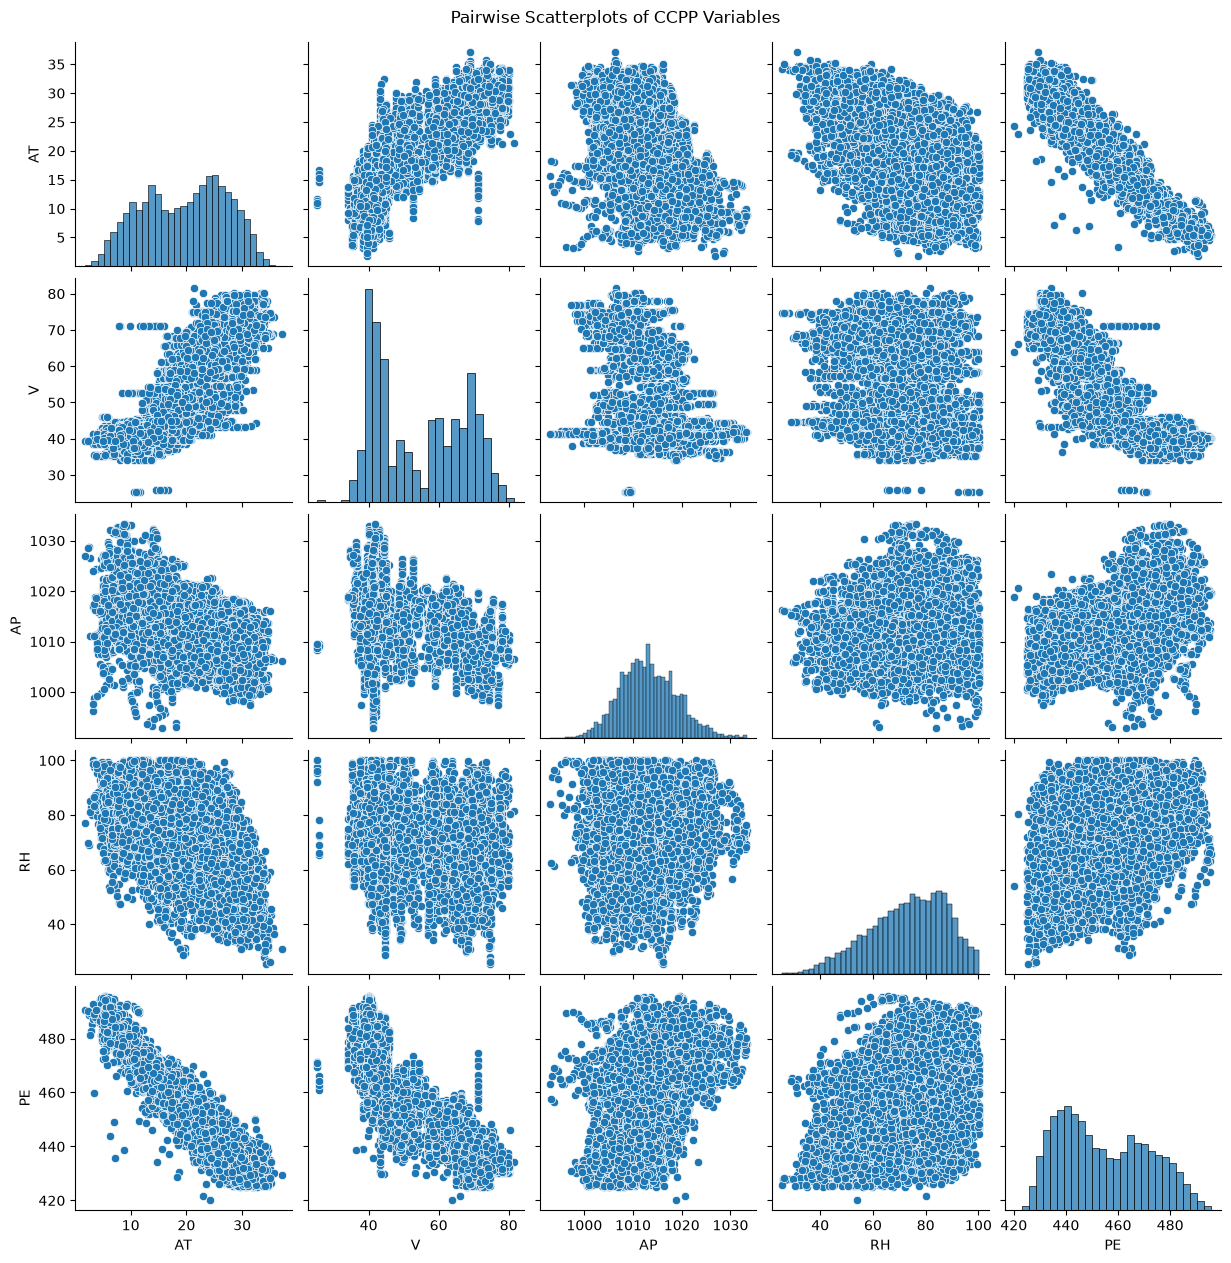

In [3]:
g=sns.pairplot(data)
g.fig.suptitle("Pairwise Scatterplots of CCPP Variables", y=1.01)
plt.show()

The pairwise scatterplots show that PE has a strong negative and possibly linear relationship with both AT and V.

As AT and V increase, PE generally decreases.

Also, PE has a weaker positive relationship with both AP and RH.

Amongst the predictors, AT and V appear to have a strong positive relationship with each other.

V appears to have a nonlinear positive relationship with AT and a nonlinear negative relationship with PE.

### 1(b)(iii) Summary statistics table

In [4]:
summary=pd.DataFrame({
    "Mean": data.mean(),
    "Median": data.median(),
    "Range": data.max()-data.min(),
    "Q1": data.quantile(0.25),
    "Q3": data.quantile(0.75),
    "IQR": data.quantile(0.75)-data.quantile(0.25)
})

summary.round(4)

,Mean,Median,Range,Q1,Q3,IQR
AT,19.6512,20.345,35.30,13.5100,25.72,12.2100
V,54.3058,52.080,56.20,41.7400,66.54,24.8000
AP,1013.2591,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.3090,74.975,74.60,63.3275,84.83,21.5025
PE,454.3650,451.550,75.50,439.7500,468.43,28.6800


## 1(c) Simple linear regression model

## 1(c) AT Model

In [5]:
X=sm.add_constant(data["AT"])
y=data["PE"]

modelAT=sm.OLS(y, X).fit()
print(modelAT.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:29:55   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        497.0341      0.156   3177.280      0.0

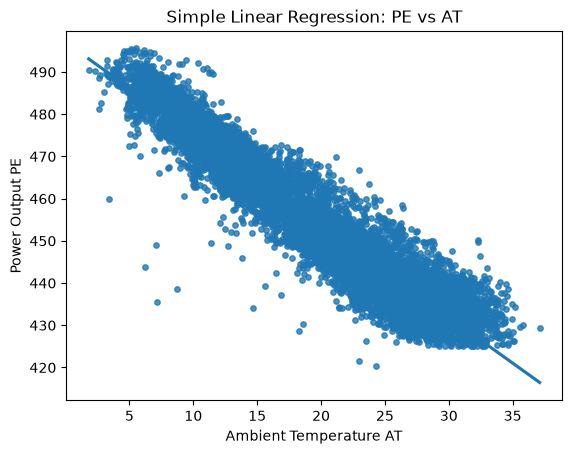

In [6]:
sns.regplot(x="AT", y="PE", data=data, scatter_kws={"s": 15})
plt.title("Simple Linear Regression: PE vs AT")
plt.xlabel("Ambient Temperature AT")
plt.ylabel("Power Output PE")
plt.show()

In [7]:
intercept=modelAT.params["const"]
coeff=modelAT.params["AT"]
R2=modelAT.rsquared
p=modelAT.pvalues["AT"]

print(f"PE = {intercept:.4f} {coeff:+.4f}(AT)")
print("R-squared: ", round(R2, 4))
print("AT p-value: ", p)

if p<0.05:
    print("Conclusion: Because p < 0.05, we reject H0. AT has a statistically significant association with PE.")
else:
    print("Conclusion: Because p >= 0.05, we fail to reject H0. AT does not have a statistically significant association with PE.")

PE = 497.0341 -2.1713(AT)
R-squared:  0.8989
AT p-value:  0.0
Conclusion: Because p < 0.05, we reject H0. AT has a statistically significant association with PE.


## 1(c) V Model

In [8]:
X=sm.add_constant(data["V"])
y=data["PE"]

modelV=sm.OLS(y, X).fit()
print(modelV.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                 2.972e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:29:56   Log-Likelihood:                -33963.
No. Observations:                9568   AIC:                         6.793e+04
Df Residuals:                    9566   BIC:                         6.794e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        517.8015      0.378   1370.218      0.0

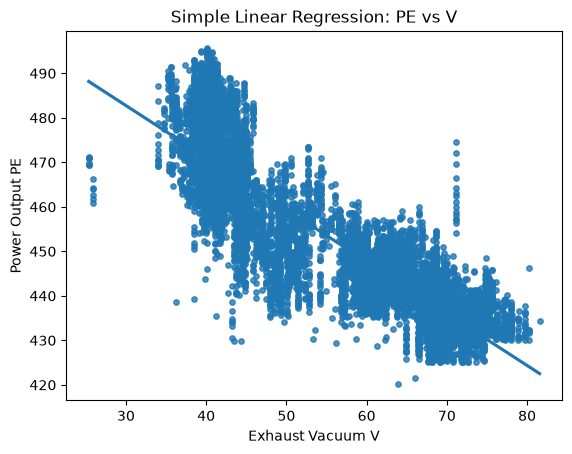

In [9]:
sns.regplot(x="V", y="PE", data=data, scatter_kws={"s": 15})
plt.title("Simple Linear Regression: PE vs V")
plt.xlabel("Exhaust Vacuum V")
plt.ylabel("Power Output PE")
plt.show()

In [10]:
intercept=modelV.params["const"]
coeff=modelV.params["V"]
R2=modelV.rsquared
p=modelV.pvalues["V"]

print(f"PE = {intercept:.4f} {coeff:+.4f}(V)")
print("R-squared: ", round(R2, 4))
print("V p-value: ", p)

if p<0.05:
    print("Conclusion: Because p < 0.05, we reject H0. V has a statistically significant association with PE.")
else:
    print("Conclusion: Because p >= 0.05, we fail to reject H0. V does not have a statistically significant association with PE.")

PE = 517.8015 -1.1681(V)
R-squared:  0.7565
V p-value:  0.0
Conclusion: Because p < 0.05, we reject H0. V has a statistically significant association with PE.


## 1(c) AP Model

In [11]:
X=sm.add_constant(data["AP"])
y=data["PE"]

modelAP=sm.OLS(y, X).fit()
print(modelAP.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     3516.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:29:56   Log-Likelihood:                -39224.
No. Observations:                9568   AIC:                         7.845e+04
Df Residuals:                    9566   BIC:                         7.847e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1055.2610     25.459    -41.449      0.0

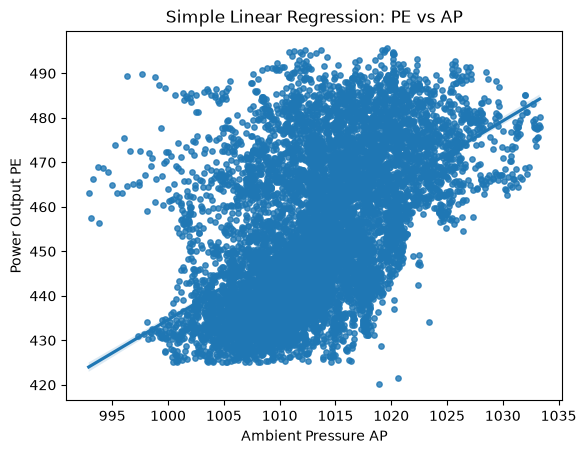

In [12]:
sns.regplot(x="AP", y="PE", data=data, scatter_kws={"s": 15})
plt.title("Simple Linear Regression: PE vs AP")
plt.xlabel("Ambient Pressure AP")
plt.ylabel("Power Output PE")
plt.show()

In [13]:
intercept=modelAP.params["const"]
coeff=modelAP.params["AP"]
R2=modelAP.rsquared
p=modelAP.pvalues["AP"]

print(f"PE = {intercept:.4f} {coeff:+.4f}(AP)")
print("R-squared: ", round(R2, 4))
print("AP p-value: ", p)

if p<0.05:
    print("Conclusion: Because p < 0.05, we reject H0. AP has a statistically significant association with PE.")
else:
    print("Conclusion: Because p >= 0.05, we fail to reject H0. AP does not have a statistically significant association with PE.")

PE = -1055.2610 +1.4899(AP)
R-squared:  0.2688
AP p-value:  0.0
Conclusion: Because p < 0.05, we reject H0. AP has a statistically significant association with PE.


## 1(c) RH Model

In [14]:
X=sm.add_constant(data["RH"])
y=data["PE"]

modelRH=sm.OLS(y, X).fit()
print(modelRH.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     1714.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:29:57   Log-Likelihood:                -39933.
No. Observations:                9568   AIC:                         7.987e+04
Df Residuals:                    9566   BIC:                         7.988e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        420.9618      0.823    511.676      0.0

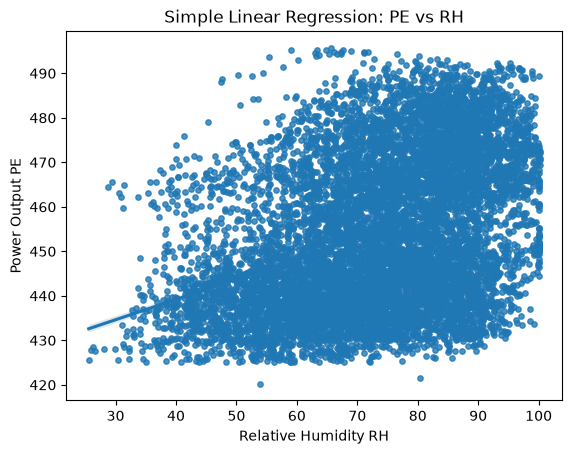

In [15]:
sns.regplot(x="RH", y="PE", data=data, scatter_kws={"s": 15})
plt.title("Simple Linear Regression: PE vs RH")
plt.xlabel("Relative Humidity RH")
plt.ylabel("Power Output PE")
plt.show()

In [16]:
intercept=modelRH.params["const"]
coeff=modelRH.params["RH"]
R2=modelRH.rsquared
p=modelRH.pvalues["RH"]

print(f"PE = {intercept:.4f} {coeff:+.4f}(RH)")
print("R-squared: ", round(R2, 4))
print("RH p-value: ", p)

if p<0.05:
    print("Conclusion: Because p < 0.05, we reject H0. RH has a statistically significant association with PE.")
else:
    print("Conclusion: Because p >= 0.05, we fail to reject H0. RH does not have a statistically significant association with PE.")

PE = 420.9618 +0.4557(RH)
R-squared:  0.1519
RH p-value:  0.0
Conclusion: Because p < 0.05, we reject H0. RH has a statistically significant association with PE.


## 1(c) Results
All four predictors, AT, V, AP, RH, have statistically significant association with PE because their p-values are less than 0.05. 
AT has the highest R^2, followed by V, AP, and RH. Therefore, AT explains the largest proportion of the variation in PE when used as the only predictor. 
The regression plots do not contain any clearly extreme outliers, so no observations are removed at this moment. 

## 1(d) Multiple regression model

In [17]:
X=data[["AT", "V", "AP", "RH"]]
X=sm.add_constant(X)
y=data["PE"]

modelMultiple=sm.OLS(y, X).fit()

print(modelMultiple.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:29:58   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

## 1(d) Multiple Linear Regression Model Results

In [18]:
print(f"PE = {modelMultiple.params['const']:.4f} {modelMultiple.params['AT']:+.4f}(AT) {modelMultiple.params['V']:+.4f}(V) {modelMultiple.params['AP']:+.4f}(AP) {modelMultiple.params['RH']:+.4f}(RH)")
print("R-squared: ", round(modelMultiple.rsquared, 4), "\n")

for predictor in ["AT", "V", "AP", "RH"]:
    p=modelMultiple.pvalues[predictor]
    print(f"{predictor} p-value: {p}")

    if p<0.05:
        print(f"Conclusion: Because p < 0.05, we reject H0. {predictor} has a statistically significant association with PE.\n")
    else:
        print(f"Conclusion: Because p >= 0.05, we fail to reject H0. {predictor} does not have a statistically significant association with PE.\n")

PE = 454.6093 -1.9775(AT) -0.2339(V) +0.0621(AP) -0.1581(RH)
R-squared:  0.9287 

AT p-value: 0.0
Conclusion: Because p < 0.05, we reject H0. AT has a statistically significant association with PE.

V p-value: 4.37530536252273e-215
Conclusion: Because p < 0.05, we reject H0. V has a statistically significant association with PE.

AP p-value: 5.507108852494091e-11
Conclusion: Because p < 0.05, we reject H0. AP has a statistically significant association with PE.

RH p-value: 3.104584420300095e-293
Conclusion: Because p < 0.05, we reject H0. RH has a statistically significant association with PE.



## 1(e) Results comparison

In [19]:
simpleCoeffs={
    "AT": modelAT.params["AT"],
    "V": modelV.params["V"],
    "AP": modelAP.params["AP"],
    "RH": modelRH.params["RH"]
}

multipleCoeffs={
    "AT": modelMultiple.params["AT"],
    "V": modelMultiple.params["V"],
    "AP": modelMultiple.params["AP"],
    "RH": modelMultiple.params["RH"]
}

for predictor in ["AT", "V", "AP", "RH"]:
    print(predictor)
    print("Simple coefficient:", round(simpleCoeffs[predictor], 4))
    print("Multiple coefficient:", round(multipleCoeffs[predictor], 4), "\n")

AT
Simple coefficient: -2.1713
Multiple coefficient: -1.9775 

V
Simple coefficient: -1.1681
Multiple coefficient: -0.2339 

AP
Simple coefficient: 1.4899
Multiple coefficient: 0.0621 

RH
Simple coefficient: 0.4557
Multiple coefficient: -0.1581 



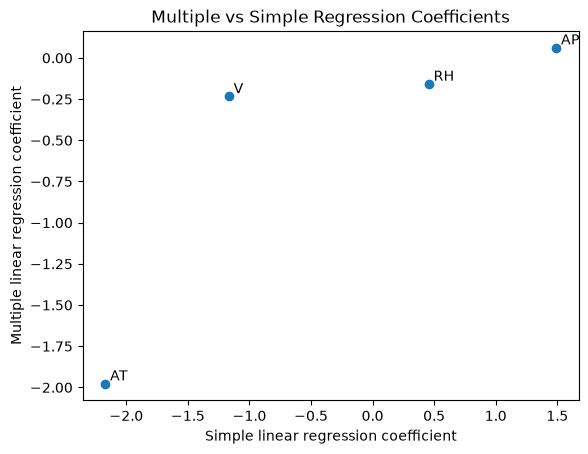

In [20]:
x=list(simpleCoeffs.values())
y=list(multipleCoeffs.values())

plt.scatter(x, y)

for i, predictor in enumerate(simpleCoeffs.keys()):
    plt.annotate(predictor, (x[i]+0.04, y[i]+0.02))

plt.xlabel("Simple linear regression coefficient")
plt.ylabel("Multiple linear regression coefficient")
plt.title("Multiple vs Simple Regression Coefficients")
plt.show()

## 1(e) Results
The simple and multiple regression coefficients differ noticeably for V, AP, and RH. 

AT only changes slightly between the two models. 

For all predictors, the multiple regression coefficient is closer to 0 than the simple regression coefficent. 

RH changes from a positive simple regression coefficient to a negative multiple regression coefficient. 

Differences between the simple and multiple regression coefficients are expected because the simple regression model considers each predictor separately, while the multiple regression model estimates each predictor's association with PE while keeping the other predictors constant. However, some predictors may be correlated with one another, so when they are included in the same model, their coefficient estimates change. 

## 1(f) Nonlinear association

In [21]:
from sklearn.preprocessing import PolynomialFeatures

### AT:

In [22]:
AT=data[["AT"]]
y=data["PE"]

poly=PolynomialFeatures(degree=3, include_bias=False)
XpolyAT=poly.fit_transform(AT)
XpolyAT=pd.DataFrame(
    XpolyAT,
    columns=["AT", "AT^2", "AT^3"]
)

XpolyAT=sm.add_constant(XpolyAT)
modelATpoly=sm.OLS(y, XpolyAT).fit()
print(modelATpoly.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:29:58   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        492.7281      0.673    732.248      0.0

In [23]:
def nlMessage(model, predictor):
    linearModels={
        "AT": modelAT,
        "V": modelV,
        "AP": modelAP,
        "RH": modelRH
    }

    linearModel=linearModels[predictor]
    
    p2=model.pvalues[f"{predictor}^2"]
    p3=model.pvalues[f"{predictor}^3"]

    print(f"{predictor}² p-value: {p2:.3e}")
    print(f"{predictor}³ p-value: {p3:.3e}")
    
    if p2<0.05 and p3<0.05:
        print(f"Both the quadratic term {predictor}² and cubic term {predictor}³ have p-values less than 0.05. Therefore, there is statistically significant evidence of a nonlinear association between {predictor} and PE.")
    elif p2<0.05:
        print(f"The quadratic term {predictor}² has a p-value less than 0.05. Therefore, there is statistically significant evidence of a nonlinear association between {predictor} and PE.")
    elif p3<0.05:
        print(f"The cubic term {predictor}³ has a p-value less than 0.05. Therefore, there is statistically significant evidence of a nonlinear association between {predictor} and PE.")
    else:
        print(f"Both the quadratic term {predictor}² and cubic term {predictor}³ have p-values greater than 0.05. Therefore, there is no statistically significant evidence of a nonlinear association between {predictor} and PE.")

    polyR=model.rsquared
    linearR=linearModel.rsquared
    print("\nCubic model R-squared: ", round(polyR, 4))
    print("Linear model R-squared: ", round(linearR, 4))

    if polyR>linearR:
        difference=polyR-linearR
        print(f"The cubic model has a higher R-squared than the linear model by {difference:.4f}, indicating the cubic model yields an improved fit over the linear model. ")
    else:
        print("The cubic model does not have a higher R-squared than the linear model, indicating the cubic model does not yield an improved fit over the linear model. ")


In [24]:
nlMessage(modelATpoly, "AT")

AT² p-value: 8.833e-73
AT³ p-value: 3.652e-110
Both the quadratic term AT² and cubic term AT³ have p-values less than 0.05. Therefore, there is statistically significant evidence of a nonlinear association between AT and PE.

Cubic model R-squared:  0.9119
Linear model R-squared:  0.8989
The cubic model has a higher R-squared than the linear model by 0.0129, indicating the cubic model yields an improved fit over the linear model. 


### V:

In [25]:
V=data[["V"]]
y=data["PE"]

poly=PolynomialFeatures(degree=3, include_bias=False)
XpolyV=poly.fit_transform(V)
XpolyV=pd.DataFrame(
    XpolyV,
    columns=["V", "V^2", "V^3"]
)

XpolyV=sm.add_constant(XpolyV)
modelVpoly=sm.OLS(y, XpolyV).fit()
print(modelVpoly.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                 1.098e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:29:58   Log-Likelihood:                -33585.
No. Observations:                9568   AIC:                         6.718e+04
Df Residuals:                    9564   BIC:                         6.721e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        554.1468      9.151     60.557      0.0

In [26]:
nlMessage(modelVpoly, "V")

V² p-value: 7.685e-01
V³ p-value: 1.373e-02
The cubic term V³ has a p-value less than 0.05. Therefore, there is statistically significant evidence of a nonlinear association between V and PE.

Cubic model R-squared:  0.775
Linear model R-squared:  0.7565
The cubic model has a higher R-squared than the linear model by 0.0185, indicating the cubic model yields an improved fit over the linear model. 


### AP:

In [27]:
AP=data[["AP"]]
y=data["PE"]

poly=PolynomialFeatures(degree=3, include_bias=False)
XpolyAP=poly.fit_transform(AP)
XpolyAP=pd.DataFrame(
    XpolyAP,
    columns=["AP", "AP^2", "AP^3"]
)

XpolyAP=sm.add_constant(XpolyAP)
modelAPpoly=sm.OLS(y, XpolyAP).fit()
print(modelAPpoly.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     1813.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:29:58   Log-Likelihood:                -39184.
No. Observations:                9568   AIC:                         7.837e+04
Df Residuals:                    9565   BIC:                         7.840e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0747      0.009      8.415      0.0

C:\Users\yinin\AppData\Local\Temp\ipykernel_29480\1382106539.py:12: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  modelAPpoly=sm.OLS(y, XpolyAP).fit()


In [28]:
nlMessage(modelAPpoly, "AP")

AP² p-value: 3.667e-17
AP³ p-value: 8.264e-18
Both the quadratic term AP² and cubic term AP³ have p-values less than 0.05. Therefore, there is statistically significant evidence of a nonlinear association between AP and PE.

Cubic model R-squared:  0.2749
Linear model R-squared:  0.2688
The cubic model has a higher R-squared than the linear model by 0.0061, indicating the cubic model yields an improved fit over the linear model. 


### RH:

In [29]:
RH=data[["RH"]]
y=data["PE"]

poly=PolynomialFeatures(degree=3, include_bias=False)
XpolyRH=poly.fit_transform(RH)
XpolyRH=pd.DataFrame(
    XpolyRH,
    columns=["RH", "RH^2", "RH^3"]
)

XpolyRH=sm.add_constant(XpolyRH)
modelRHpoly=sm.OLS(y, XpolyRH).fit()
print(modelRHpoly.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     579.2
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:29:58   Log-Likelihood:                -39923.
No. Observations:                9568   AIC:                         7.985e+04
Df Residuals:                    9564   BIC:                         7.988e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        468.4135     10.545     44.422      0.0

In [30]:
nlMessage(modelRHpoly, "RH")

RH² p-value: 9.395e-06
RH³ p-value: 1.440e-05
Both the quadratic term RH² and cubic term RH³ have p-values less than 0.05. Therefore, there is statistically significant evidence of a nonlinear association between RH and PE.

Cubic model R-squared:  0.1537
Linear model R-squared:  0.1519
The cubic model has a higher R-squared than the linear model by 0.0018, indicating the cubic model yields an improved fit over the linear model. 


## 1(f) Results

For each predictor, at least one of the nonlinear terms X² or X³ has a p-value less than 0.05. 

There is statistically significant evidence of a nonlinear association between each predictor and PE. 

To further support, the cubic polynomial models also have higher R² values than their corresponding simple linear regression models, indicating an improved model fit when including nonlinear terms. 

## 1(g) Interactions of predictors with response

In [31]:
X=data[["AT", "V", "AP", "RH"]]

interaction=PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
Xinteractions=interaction.fit_transform(X)
Xinteractions=pd.DataFrame(
    Xinteractions,
    columns=interaction.get_feature_names_out(X.columns)
)
Xinteractions=sm.add_constant(Xinteractions)

modelInteractions=sm.OLS(y, Xinteractions).fit()

print(modelInteractions.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:29:58   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        685.7825     78.640      8.721      0.0

In [32]:
interactionTerms=["AT V", "AT AP", "AT RH", "V AP", "V RH", "AP RH"]

for term in interactionTerms:
    p=modelInteractions.pvalues[term]

    if p<0.05:
        print(f"{term}: Because p = {p:.3e} is less than 0.05, there is statistically significant evidence of association of interactions.\n")
    else:
        print(f"{term}: Because p = {p:.3e} is not less than 0.05, there is no statistically significant evidence of association of interactions.\n")

AT V: Because p = 3.333e-117 is less than 0.05, there is statistically significant evidence of association of interactions.

AT AP: Because p = 4.521e-01 is not less than 0.05, there is no statistically significant evidence of association of interactions.

AT RH: Because p = 1.217e-10 is less than 0.05, there is statistically significant evidence of association of interactions.

V AP: Because p = 2.877e-07 is less than 0.05, there is statistically significant evidence of association of interactions.

V RH: Because p = 8.619e-02 is not less than 0.05, there is no statistically significant evidence of association of interactions.

AP RH: Because p = 3.361e-02 is less than 0.05, there is statistically significant evidence of association of interactions.



## 1(g) Results

The interaction terms [AT, V], [AT, RH], [V, AP], and [AP, RH] have p-values less than 0.05 and are statistically significant. 

The interaction terms [AT, AP] and [V, RH] have p-values greater than 0.05 and are not statistically significant. 

Therefore, there is evidence that some interactions between predictors are associated with the response. 

## 1(h) Improved model

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## 1(h) Baseline multiple linear regression

In [34]:
X=data[["AT", "V", "AP", "RH"]]
y=data["PE"]

XTrain, XTest, yTrain, yTest=train_test_split(X, y, test_size=0.30, random_state=1)

print("Training observations: ", len(XTrain))
print("Test observations: ", len(XTest))

Training observations:  6697
Test observations:  2871


In [35]:
XTrainConst=sm.add_constant(XTrain)
XTestConst=sm.add_constant(XTest)

linearModelTrain=sm.OLS(yTrain, XTrainConst).fit()

trainPredict=linearModelTrain.predict(XTrainConst)
testPredict=linearModelTrain.predict(XTestConst)

trainLinearMSE=mean_squared_error(yTrain, trainPredict)
testLinearMSE=mean_squared_error(yTest, testPredict)

print("Linear model training MSE: ", round(trainLinearMSE, 4))
print("Linear model test MSE: ", round(testLinearMSE, 4))

Linear model training MSE:  20.7661
Linear model test MSE:  20.7775


The training MSE and testing MSE are very similar, suggesting that the model applies well to unseen data and is not overfitting. 

## 1(h) Regression model with all possible interaction terms and quadratic nonlinearities

In [36]:
poly2=PolynomialFeatures(degree=2, include_bias=False)

XTrainPoly=poly2.fit_transform(XTrain)
XTestPoly=poly2.transform(XTest)

featureNames=poly2.get_feature_names_out(XTrain.columns)

XTrainPoly=pd.DataFrame(XTrainPoly, columns=featureNames, index=XTrain.index)
XTestPoly=pd.DataFrame(XTestPoly, columns=featureNames, index=XTest.index)

XTrainPoly=sm.add_constant(XTrainPoly)
XTestPoly=sm.add_constant(XTestPoly)

polyModelTrain=sm.OLS(yTrain, XTrainPoly).fit()
print(polyModelTrain.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7181.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:29:58   Log-Likelihood:                -19192.
No. Observations:                6697   AIC:                         3.841e+04
Df Residuals:                    6682   BIC:                         3.852e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -8171.8080   1416.708     -5.768      0.0

### Eliminate [AT, AP] since it has the largest p-value

In [37]:
XTrainReduced=XTrainPoly.drop(columns=["AT AP"])
XTestReduced=XTestPoly.drop(columns=["AT AP"])

reducedModel=sm.OLS(yTrain, XTrainReduced).fit()
print(reducedModel.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7735.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:29:59   Log-Likelihood:                -19192.
No. Observations:                6697   AIC:                         3.841e+04
Df Residuals:                    6683   BIC:                         3.851e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -8407.6645   1239.629     -6.782      0.0

### Eliminate [V, RH] since it has the largest p-value

In [38]:
XTrainReduced2=XTrainReduced.drop(columns=["V RH"])
XTestReduced2=XTestReduced.drop(columns=["V RH"])

reducedModel2=sm.OLS(yTrain, XTrainReduced2).fit()
print(reducedModel2.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     8380.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:29:59   Log-Likelihood:                -19192.
No. Observations:                6697   AIC:                         3.841e+04
Df Residuals:                    6684   BIC:                         3.850e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -8455.2645   1237.872     -6.830      0.0

### Eliminate V² since it has the largest p-value

In [39]:
XTrainReduced3=XTrainReduced2.drop(columns=["V^2"])
XTestReduced3=XTestReduced2.drop(columns=["V^2"])

finalModel=sm.OLS(yTrain, XTrainReduced3).fit()
print(finalModel.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     9142.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:29:59   Log-Likelihood:                -19193.
No. Observations:                6697   AIC:                         3.841e+04
Df Residuals:                    6685   BIC:                         3.849e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -8533.1836   1234.561     -6.912      0.0

### All remaining terms p<0.05; removed [AT, AP], [V, RH], V²

In [40]:
trainPredFinal=finalModel.predict(XTrainReduced3)
testPredFinal=finalModel.predict(XTestReduced3)

trainMSEFinal=mean_squared_error(yTrain, trainPredFinal)
testMSEFinal=mean_squared_error(yTest, testPredFinal)

print("Reduced nonlinear model training MSE: ", round(trainMSEFinal, 4))
print("Reduced nonlinear model test MSE: ", round(testMSEFinal, 4), "\n")

print("Baseline linear model training MSE: ", round(trainLinearMSE, 4))
print("Baseline linear model test MSE: ", round(testLinearMSE, 4))

Reduced nonlinear model training MSE:  18.0637
Reduced nonlinear model test MSE:  18.2322 

Baseline linear model training MSE:  20.7661
Baseline linear model test MSE:  20.7775


## 1(h) Results

The baseline multiple linear regression model had a training MSE of 20.7661 and a test MSE of 20.7775.

The reduced nonlinear regression model had a training MSE of 18.0637 and a test MSE of 18.2322, which are very similar.

Because both the training and testing MSE values decreased, the reduced nonlinear regression model improves prediction performance compared to the baseline linear model.

Because the training and testing MSE values are also similar, the reduced nonlinear model also does not appear to be overfitted.

## 1(i) KNN regression

In [41]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

### Raw features

In [42]:
kVals=range(1, 101)
rawTrainMSE=[]
rawTestMSE=[]

for k in kVals:
    knn=KNeighborsRegressor(n_neighbors=k)
    knn.fit(XTrain, yTrain)

    trainPred=knn.predict(XTrain)
    testPred=knn.predict(XTest)

    rawTrainMSE.append(mean_squared_error(yTrain, trainPred))
    rawTestMSE.append(mean_squared_error(yTest, testPred))

bestKRaw=kVals[rawTestMSE.index(min(rawTestMSE))]

print("Best raw features k: ", bestKRaw)
print(f"Best raw feature test MSE: {min(rawTestMSE):.4f}")

Best raw features k:  5
Best raw feature test MSE: 15.7048


### Normalized features

In [43]:
scaler=StandardScaler()
XTrainScaled=scaler.fit_transform(XTrain)
XTestScaled=scaler.transform(XTest)

scaledTrainMSE=[]
scaledTestMSE=[]

for k in kVals:
    knn=KNeighborsRegressor(n_neighbors=k)
    knn.fit(XTrainScaled, yTrain)

    trainPred=knn.predict(XTrainScaled)
    testPred=knn.predict(XTestScaled)

    scaledTrainMSE.append(mean_squared_error(yTrain, trainPred))
    scaledTestMSE.append(mean_squared_error(yTest, testPred))

bestKScaled=kVals[scaledTestMSE.index(min(scaledTestMSE))]

print("Best normalized features k: ", bestKScaled)
print(f"Best normalized feature test MSE: {min(scaledTestMSE):.4f}")

Best normalized features k:  4
Best normalized feature test MSE: 14.0706


### Plot train and test errors

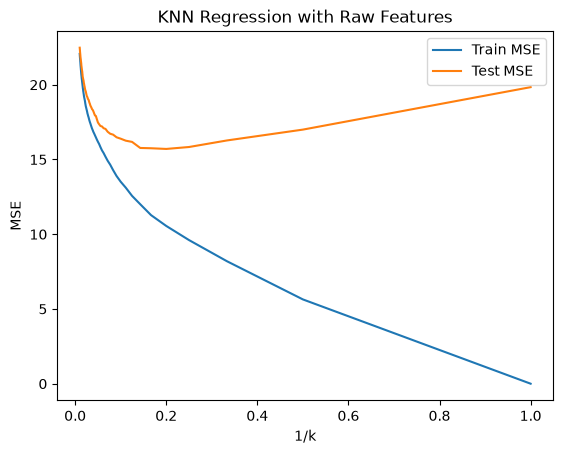

In [44]:
invK=[1/k for k in kVals]

plt.plot(invK, rawTrainMSE, label="Train MSE")
plt.plot(invK, rawTestMSE, label="Test MSE")
plt.xlabel("1/k")
plt.ylabel("MSE")
plt.title("KNN Regression with Raw Features")
plt.legend()
plt.show()

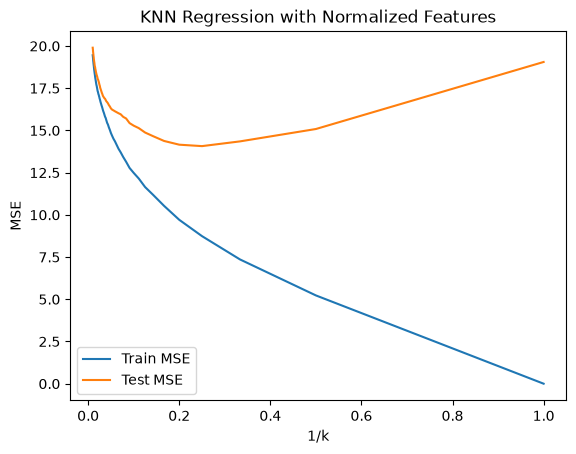

In [45]:
invK=[1/k for k in kVals]

plt.plot(invK, scaledTrainMSE, label="Train MSE")
plt.plot(invK, scaledTestMSE, label="Test MSE")
plt.xlabel("1/k")
plt.ylabel("MSE")
plt.title("KNN Regression with Normalized Features")
plt.legend()
plt.show()

### 1(i) Results

When using raw features, the best KNN model occurs at k=5 with a test MSE of 15.7048. 

When using normalized features, the best KNN model occurs at k=4 with a test MSE of 14.0706. 

The normalized feature KNN model therefore performs better because it has the lower test MSE. 

## 1(j) KNN regression vs linear regression

The best regression model comes from the reduced nonlinear model from 1(h). Its test MSE is 18.2322.

The best KNN model comes from using normalized features with k=4. It has a test MSE of 14.0706. 

Because the normalized KNN model has a lower test MSE, it provides better predictive performance on the test data than the regression model. 

This suggests that KNN regression is better at capturing the nonlinear relationships between the predictors and PE for this dataset. 

# 2. ISLR 2.4.1

For each of parts (a) through (d), indicate whether we would generally
expect the performance of a flexible statistical learning method to be
better or worse than an inflexible method. Justify your answer.

(a) The sample size n is extremely large, and the number of predictors p is small.

(b) The number of predictors p is extremely large, and the number
of observations n is small.

(c) The relationship between the predictors and response is highly
non-linear.

(d) The variance of the error terms, i.e. σ2 = Var(ϵ), is extremely
high.

### Answer

a) Flexible statistical learning method is better than inflexible method. Because n is very large and p is small, there is enough data to fit a flexible model with a low risk of overfitting. 

b) Flexible method is worse than inflexible method. A small n and relatively high p makes the flexible model prone to overfitting and have high variance. 

c) Flexible method is better than inflexible method. Flexible method can capture the nonlinear relationships between the predictors and response by adapting to the curves and bends. 

d) Flexible method is worse than inflexible method. The flexible method will try to fit the noise as a result of high error variance, leading to overfitting. 

# 3. ISLR 2.4.7

The table below provides a training data set containing six observations, three predictors, and one qualitative response variable.

\------------------------------------------  
Obs.&emsp;&ensp;X1&ensp;&ensp;&ensp;&ensp;&ensp;X2&ensp;&ensp;&ensp;&ensp; X3&ensp;&ensp;&ensp;&ensp;&ensp;Y  
1&emsp;&emsp;&emsp;0&emsp;&emsp;&emsp;3&emsp;&emsp;&emsp;0&emsp;&emsp;&emsp;Red  
2&emsp;&emsp;&emsp;2&emsp;&emsp;&emsp;0&emsp;&emsp;&emsp;0&emsp;&emsp;&emsp;Red  
3&emsp;&emsp;&emsp;0&emsp;&emsp;&emsp;1&emsp;&emsp;&emsp;3&emsp;&emsp;&emsp;Red  
4&emsp;&emsp;&emsp;0&emsp;&emsp;&emsp;1&emsp;&emsp;&emsp;2&emsp;&emsp;&emsp;Green  
5&emsp;&emsp; −1&emsp;&emsp;&emsp;0&emsp;&emsp;&emsp;1&emsp;&emsp;&emsp;Green  
6&emsp;&emsp;&emsp;1&emsp;&emsp;&emsp;1&emsp;&emsp;&emsp;1&emsp;&emsp;&emsp;Red

Suppose we wish to use this data set to make a prediction for Y when
X1 = X2 = X3 =0 using K-nearest neighbors.
    
(a) Compute the Euclidean distance between each observation and
the test point, X1 = X2 = X3 =0.
    
(b) What is our prediction with K =1? Why?

(c) What is our prediction with K =3? Why?

(d) If the Bayes decision boundary in this problem is highly nonlinear, then would we expect the best value for K to be large or
small? Why?

### Answer

#### a)

In [46]:
data247=pd.DataFrame({
    "Obs": [1, 2, 3, 4, 5, 6],
    "X1": [0, 2, 0, 0, -1, 1],
    "X2": [3, 0, 1, 1, 0, 1],
    "X3": [0, 0, 3, 2, 1, 1],
    "Y": ["Red", "Red", "Red", "Green", "Green", "Red"]
})

testPoint=[0, 0, 0]

data247["Distance"]=np.sqrt(
    (data247["X1"]-testPoint[0])**2+(data247["X2"]-testPoint[1])**2+(data247["X3"]-testPoint[2])**2
)

print(data247.to_string(index=False))

 Obs  X1  X2  X3     Y  Distance
   1   0   3   0   Red  3.000000
   2   2   0   0   Red  2.000000
   3   0   1   3   Red  3.162278
   4   0   1   2 Green  2.236068
   5  -1   0   1 Green  1.414214
   6   1   1   1   Red  1.732051


#### b)

In [47]:
nearestIndex=data247["Distance"].idxmin()

print("Nearest observation: ", nearestIndex+1)
print("Prediction for K=1: ", data247.Y[nearestIndex])

Nearest observation:  5
Prediction for K=1:  Green


With K=1, KNN only looks at the single closest observation, which is 5. Its class is Green, therefore the majority is Green, and the prediction is Green. 

#### c)

In [48]:
threeNearest=data247.nsmallest(3, "Distance")

print("Nearest observations: ", list(threeNearest["Obs"]))
print("3 nearest classes: ", list(threeNearest["Y"]))

redCount=0
greenCount=0
for i in list(threeNearest["Y"]):
    if i=="Green":
        greenCount+=1
    elif i=="Red":
        redCount+=1

if redCount>greenCount:
    print("Prediction for K=3: Red")
elif greenCount>redCount:
    print("Prediction for K=3: Green")

Nearest observations:  [5, 6, 2]
3 nearest classes:  ['Green', 'Red', 'Red']
Prediction for K=3: Red


With K=3, KNN looks at the 3 closest observations, which are 5, 6, and 2. Their classes are Green, Red, and Red. The majority class is Red, therefore the prediction is Red. 

#### d)

If the Bayes decision boundary is highly nonlinear, then we expect the best value for K to be small. A smaller K gives KNN a more flexible decision boundary, allowing it to better capture a nonlinear Bayes decision boundary. A large K would create a smoother, less flexible boundary, which would be less ideal for a nonlinear Bayes decision boundary. 